# Notebook 07
# Dataset Audit

Notebook ini digunakan untuk menganalisis audio yang salah diprediksi oleh model CNN.

Output:

- Audio
- Waveform
- Mel Spectrogram
- Confidence
- Prediction
- Insight

In [12]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

import os

import librosa

import librosa.display

import matplotlib.pyplot as plt

import pandas as pd

import numpy as np

from IPython.display import Audio

In [2]:
# ==========================================================
# LOAD CSV
# ==========================================================

prediction_df = pd.read_csv(

    "prediction_result.csv"

)

wrong_df = pd.read_csv(

    "wrong_prediction.csv"

)

print(

    "Prediction :", len(prediction_df)

)

print(

    "Wrong :", len(wrong_df)
)

Prediction : 1721
Wrong : 529


In [3]:
# ==========================================================
# HAPPINESS ERROR
# ==========================================================

happy_error = wrong_df[

    wrong_df["Actual"] == "Happiness"

]

happy_error.head(20)

,Filename,Actual,Predicted,Confidence,Correct,Duration
304,happiness002.wav,Happiness,Neutral,51.86,False,3.00
305,happiness013.wav,Happiness,Neutral,44.08,False,3.59
306,happiness015.wav,Happiness,Sadness,45.46,False,1.71
307,happiness016.wav,Happiness,Neutral,34.42,False,2.84
308,happiness018.wav,Happiness,Sadness,42.81,False,2.63
309,happiness019.wav,Happiness,Sadness,40.53,False,4.05
310,happiness020.wav,Happiness,Neutral,44.19,False,2.21
311,happiness021.wav,Happiness,Sadness,57.78,False,2.04
312,happiness022.wav,Happiness,Sadness,49.34,False,1.25
313,happiness023.wav,Happiness,Sadness,90.72,False,1.50


In [4]:
# ==========================================================
# TOP HAPPINESS ERROR
# ==========================================================

happy_error.sort_values(

    by="Confidence",

    ascending=False

).head(10)

,Filename,Actual,Predicted,Confidence,Correct,Duration
524,happiness441.wav,Happiness,Neutral,99.78,False,3.02
488,happiness368.wav,Happiness,Neutral,97.95,False,3.08
494,happiness377.wav,Happiness,Neutral,92.64,False,3.02
501,happiness384.wav,Happiness,Neutral,91.14,False,3.01
313,happiness023.wav,Happiness,Sadness,90.72,False,1.50
508,happiness401.wav,Happiness,Neutral,90.38,False,3.02
506,happiness396.wav,Happiness,Anger,88.75,False,2.92
373,happiness142.wav,Happiness,Neutral,88.37,False,5.04
429,happiness244.wav,Happiness,Sadness,87.96,False,2.12
492,happiness375.wav,Happiness,Neutral,87.47,False,3.06


In [5]:
# ==========================================================
# GET AUDIO PATH
# ==========================================================

def get_audio_path(row):

    emotion_folder = {

        "Anger": "01_Anger",

        "Sadness": "02_Sadness",

        "Neutral": "03_Neutral",

        "Happiness": "04_Happiness"

    }

    folder = emotion_folder[

        row["Actual"]

    ]

    audio_path = os.path.join(

        "Dataset_Final_Indonesia",

        folder,

        row["Filename"]

    )

    return audio_path

In [6]:
# ==========================================================
# SELECT AUDIO
# ==========================================================

sample = happy_error.sort_values(

    by="Confidence",

    ascending=False

).iloc[0]

sample

Filename      happiness441.wav
Actual               Happiness
Predicted              Neutral
Confidence               99.78
Correct                  False
Duration                  3.02
Name: 524, dtype: object

In [7]:
# ==========================================================
# AUDIO PATH
# ==========================================================

audio_path = get_audio_path(

    sample

)

print(audio_path)

Dataset_Final_Indonesia\04_Happiness\happiness441.wav


In [8]:
# ==========================================================
# LOAD AUDIO
# ==========================================================

audio, sr = librosa.load(

    audio_path,

    sr=16000

)

print(

    "Sampling Rate :", sr

)

print(

    "Samples :", len(audio)

)

Sampling Rate : 16000
Samples : 48298


In [9]:
# ==========================================================
# PLAY AUDIO
# ==========================================================

Audio(

    audio,

    rate=sr

)

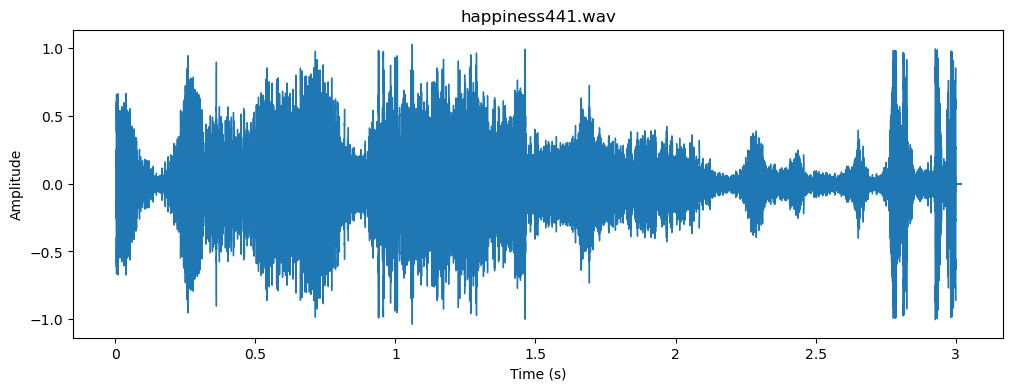

In [10]:
# ==========================================================
# WAVEFORM
# ==========================================================

plt.figure(

    figsize=(12,4)

)

librosa.display.waveshow(

    audio,

    sr=sr

)

plt.title(

    f"{sample['Filename']}"

)

plt.xlabel(

    "Time (s)"

)

plt.ylabel(

    "Amplitude"

)

plt.show()

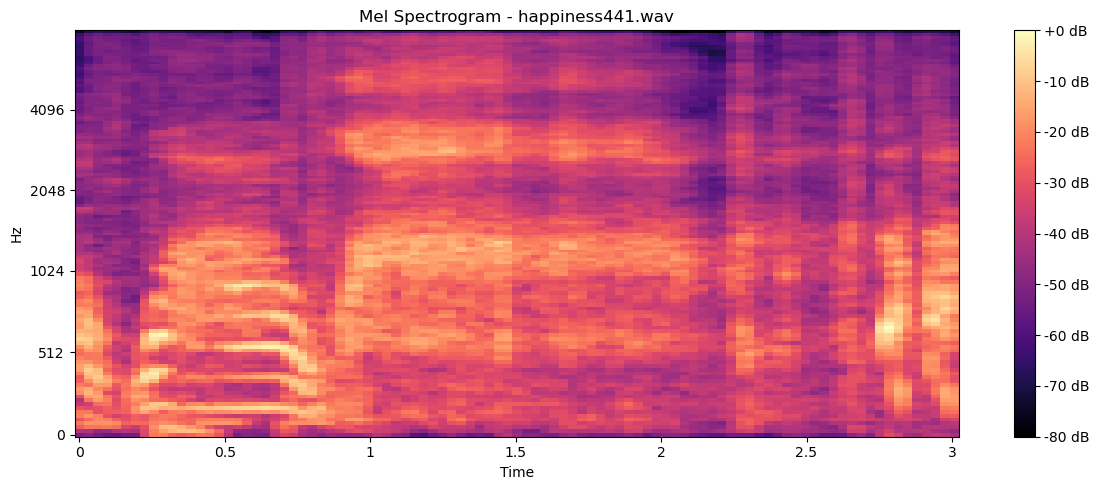

In [13]:
# ==========================================================
# MEL SPECTROGRAM
# ==========================================================

mel = librosa.feature.melspectrogram(

    y=audio,

    sr=sr,

    n_mels=128

)

mel_db = librosa.power_to_db(

    mel,

    ref=np.max

)

plt.figure(

    figsize=(12,5)

)

librosa.display.specshow(

    mel_db,

    sr=sr,

    x_axis="time",

    y_axis="mel"

)

plt.colorbar(

    format="%+2.0f dB"

)

plt.title(

    f"Mel Spectrogram - {sample['Filename']}"

)

plt.tight_layout()

plt.show()

In [14]:
# ==========================================================
# AUDIO INFORMATION
# ==========================================================

print("=" * 50)

print("Filename   :", sample["Filename"])

print("Actual     :", sample["Actual"])

print("Prediction :", sample["Predicted"])

print(f"Confidence : {sample['Confidence']:.2f}%")

print(f"Duration   : {sample['Duration']:.2f} s")

print("=" * 50)

Filename   : happiness441.wav
Actual     : Happiness
Prediction : Neutral
Confidence : 99.78%
Duration   : 3.02 s


In [15]:
# ==========================================================
# TOP 10 HAPPINESS -> NEUTRAL
# ==========================================================

happy_to_neutral = wrong_df[
    (wrong_df["Actual"] == "Happiness") &
    (wrong_df["Predicted"] == "Neutral")
].sort_values(
    by="Confidence",
    ascending=False
)

happy_to_neutral.head(10)

,Filename,Actual,Predicted,Confidence,Correct,Duration
524,happiness441.wav,Happiness,Neutral,99.78,False,3.02
488,happiness368.wav,Happiness,Neutral,97.95,False,3.08
494,happiness377.wav,Happiness,Neutral,92.64,False,3.02
501,happiness384.wav,Happiness,Neutral,91.14,False,3.01
508,happiness401.wav,Happiness,Neutral,90.38,False,3.02
373,happiness142.wav,Happiness,Neutral,88.37,False,5.04
492,happiness375.wav,Happiness,Neutral,87.47,False,3.06
504,happiness388.wav,Happiness,Neutral,84.93,False,3.02
490,happiness371.wav,Happiness,Neutral,83.94,False,3.76
496,happiness379.wav,Happiness,Neutral,81.16,False,3.03


In [16]:
# ==========================================================
# TOP 10 HAPPINESS -> SADNESS
# ==========================================================

happy_to_sadness = wrong_df[
    (wrong_df["Actual"] == "Happiness") &
    (wrong_df["Predicted"] == "Sadness")
].sort_values(
    by="Confidence",
    ascending=False
)

happy_to_sadness.head(10)

,Filename,Actual,Predicted,Confidence,Correct,Duration
313,happiness023.wav,Happiness,Sadness,90.72,False,1.50
429,happiness244.wav,Happiness,Sadness,87.96,False,2.12
371,happiness139.wav,Happiness,Sadness,86.07,False,4.08
424,happiness237.wav,Happiness,Sadness,84.49,False,3.04
388,happiness164.wav,Happiness,Sadness,82.73,False,3.88
325,happiness041.wav,Happiness,Sadness,80.94,False,1.42
415,happiness220.wav,Happiness,Sadness,80.16,False,2.38
515,happiness424.wav,Happiness,Sadness,76.14,False,3.02
516,happiness425.wav,Happiness,Sadness,72.88,False,3.02
519,happiness429.wav,Happiness,Sadness,69.95,False,3.02


In [17]:
# ==========================================================
# TOP 10 NEUTRAL -> SADNESS
# ==========================================================

neutral_to_sadness = wrong_df[
    (wrong_df["Actual"] == "Neutral") &
    (wrong_df["Predicted"] == "Sadness")
].sort_values(
    by="Confidence",
    ascending=False
)

neutral_to_sadness.head(10)

,Filename,Actual,Predicted,Confidence,Correct,Duration
224,neutral147.wav,Neutral,Sadness,88.35,False,1.62
239,neutral173.wav,Neutral,Sadness,87.54,False,3.62
157,neutral037.wav,Neutral,Sadness,87.38,False,2.38
217,neutral138.wav,Neutral,Sadness,86.47,False,2.12
219,neutral142.wav,Neutral,Sadness,84.91,False,2.04
238,neutral172.wav,Neutral,Sadness,82.50,False,1.75
206,neutral118.wav,Neutral,Sadness,82.50,False,1.38
289,neutral287.wav,Neutral,Sadness,80.08,False,2.38
227,neutral154.wav,Neutral,Sadness,79.54,False,2.29
277,neutral265.wav,Neutral,Sadness,79.48,False,1.62


In [21]:
# ==========================================================
# INTERACTIVE AUDIO AUDIT
# ==========================================================

def audit_audio(index, dataframe=happy_to_neutral):

    row = dataframe.iloc[index]

    audio_path = get_audio_path(row)

    audio, sr = librosa.load(
        audio_path,
        sr=16000
    )

    print("=" * 60)
    print(f"Index      : {index}")
    print(f"Filename   : {row['Filename']}")
    print(f"Actual     : {row['Actual']}")
    print(f"Prediction : {row['Predicted']}")
    print(f"Confidence : {row['Confidence']:.2f}%")
    print(f"Duration   : {row['Duration']:.2f} s")
    print("=" * 60)

    display(Audio(audio, rate=sr))

    plt.figure(figsize=(12,4))

    librosa.display.waveshow(
        audio,
        sr=sr
    )

    plt.title(f"Waveform - {row['Filename']}")

    plt.tight_layout()

    plt.show()

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    plt.figure(figsize=(12,5))

    librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis="time",
        y_axis="mel"
    )

    plt.colorbar(format="%+2.0f dB")

    plt.title(f"Mel Spectrogram - {row['Filename']}")

    plt.tight_layout()

    plt.show()

Index      : 0
Filename   : happiness441.wav
Actual     : Happiness
Prediction : Neutral
Confidence : 99.78%
Duration   : 3.02 s


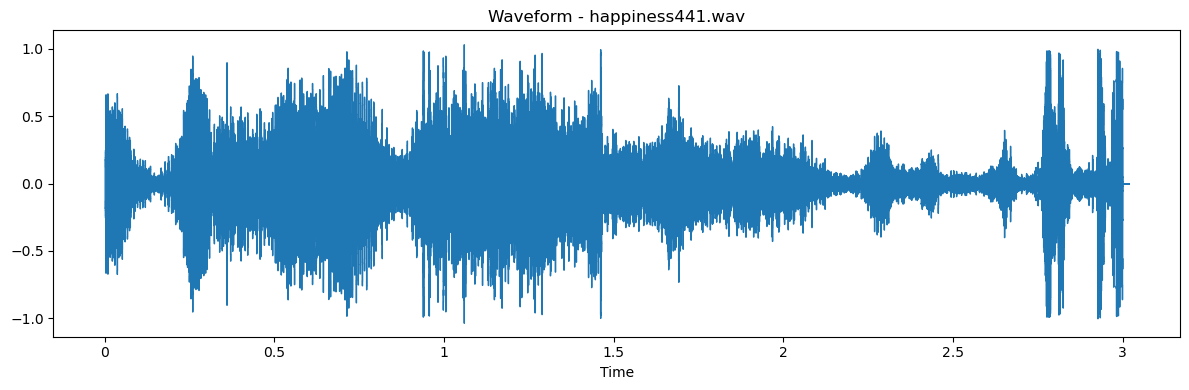

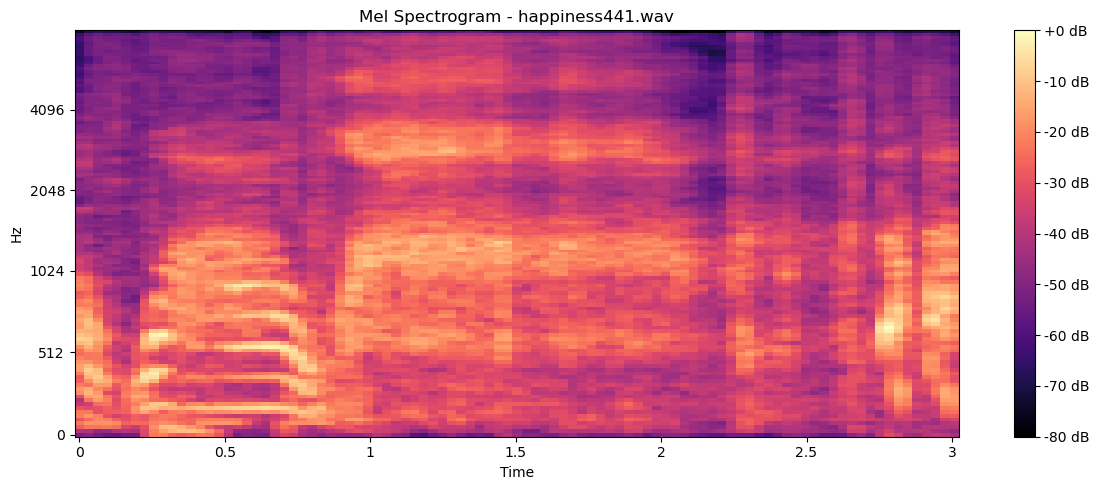

In [22]:
audit_audio(0)

Index      : 1
Filename   : happiness368.wav
Actual     : Happiness
Prediction : Neutral
Confidence : 97.95%
Duration   : 3.08 s


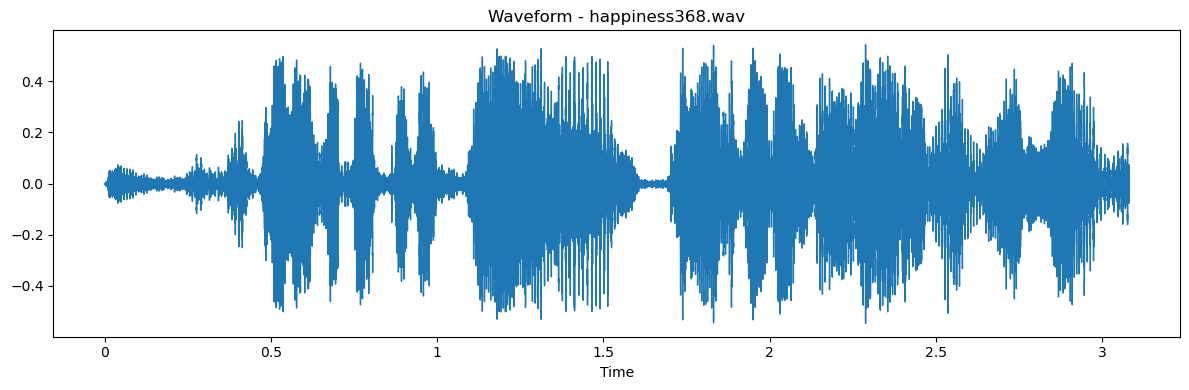

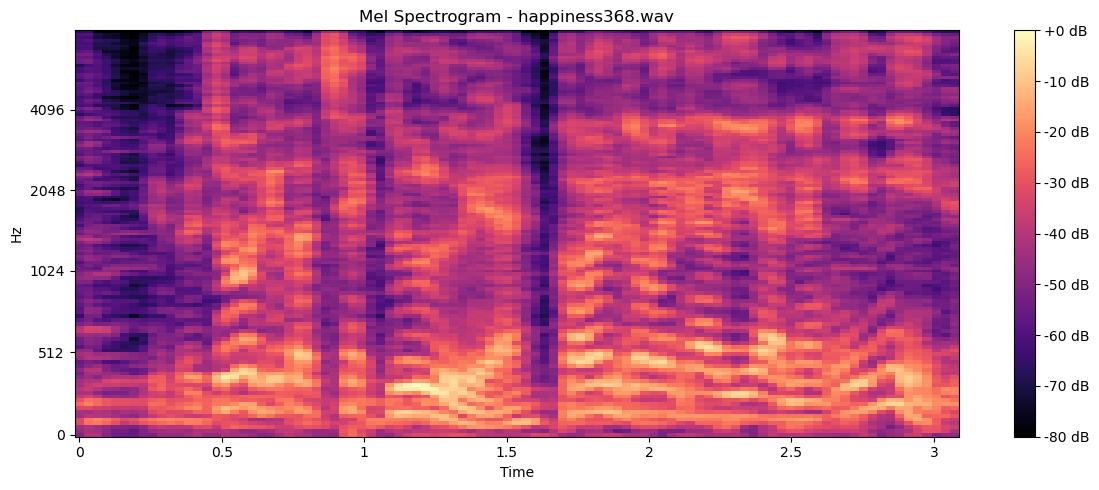

In [23]:
audit_audio(1)

Index      : 2
Filename   : happiness377.wav
Actual     : Happiness
Prediction : Neutral
Confidence : 92.64%
Duration   : 3.02 s


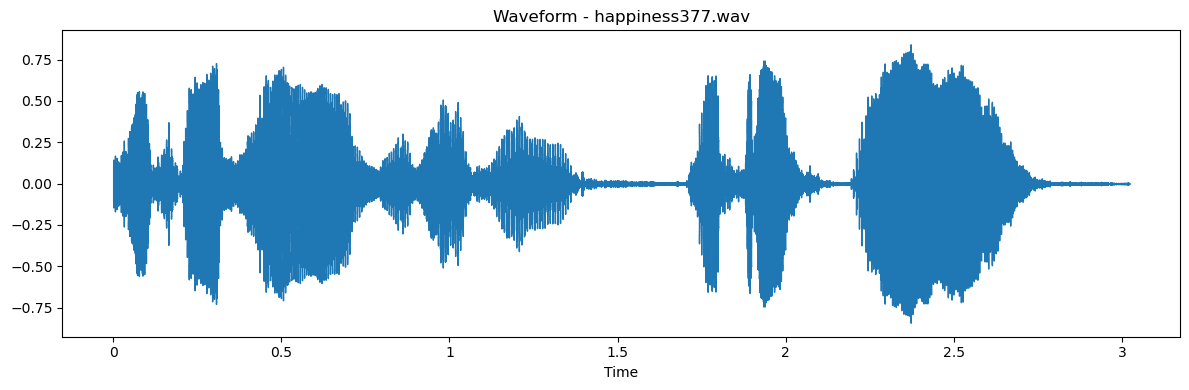

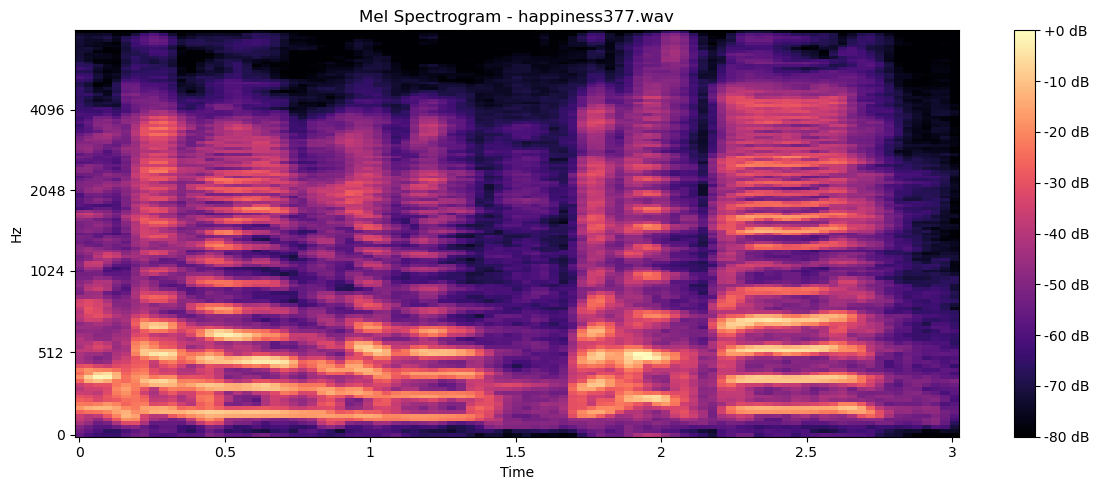

In [24]:
audit_audio(2)